In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import pi as pi
from numpy import sqrt as sqrt
from qutip import *

In [4]:
# parameter
wr = 2.0 * 2 * pi      # resonator frequency
wq1 = 3.5 * 2 * pi     # qubit 1 frequency
wq2 = 3.5 * 2 * pi     # qubit 2 frequency, degenerate qubits
g1 = 0.1 * 2 * pi
g2 = 0.1 * 2 * pi
N = 15

# detuning and shift
delta_1 = wq1 - wr
delta_2 = wq2 - wr
chi_1 = g1**2 / delta_1
chi_2 = g2**2 / delta_2

In [5]:
# Operators
a = tensor(destroy(N), qeye(2), qeye(2))  # cavity annihilation
sm1 = tensor(qeye(N), destroy(2), qeye(2))  # qubit 1 lowering
sm2 = tensor(qeye(N), qeye(2), destroy(2))  # qubit 2 lowering

sz1 = tensor(qeye(N), sigmaz(), qeye(2))
sz2 = tensor(qeye(N), qeye(2), sigmaz())

# Qubit Hamiltonians
Hq1 = (wq1 / 2) * sz1
Hq2 = (wq2 / 2) * sz2

# Cavity Hamiltonian
Hr = wr * a.dag() * a

# Interaction Hamiltonian
Hint1 = g1 * (a + a.dag()) * (sm1 + sm1.dag())
Hint2 = g2 * (a + a.dag()) * (sm2 + sm2.dag())

# Total Hamiltonian
H = Hq1 + Hq2 + Hr + Hint1 + Hint2

# Qubit-qubit interaction

In [13]:
# Initial state, qubit state 10
psi0 = tensor(coherent(N,2), basis(2,1), basis(2,0))

# Time evolution
tlist0 = np.linspace(0, 500, 5000)

# Zero dissipation
c_ops0 = []
result0 = mesolve(H, psi0, tlist0, c_ops0, [a.dag()*a, sz1, sz2])

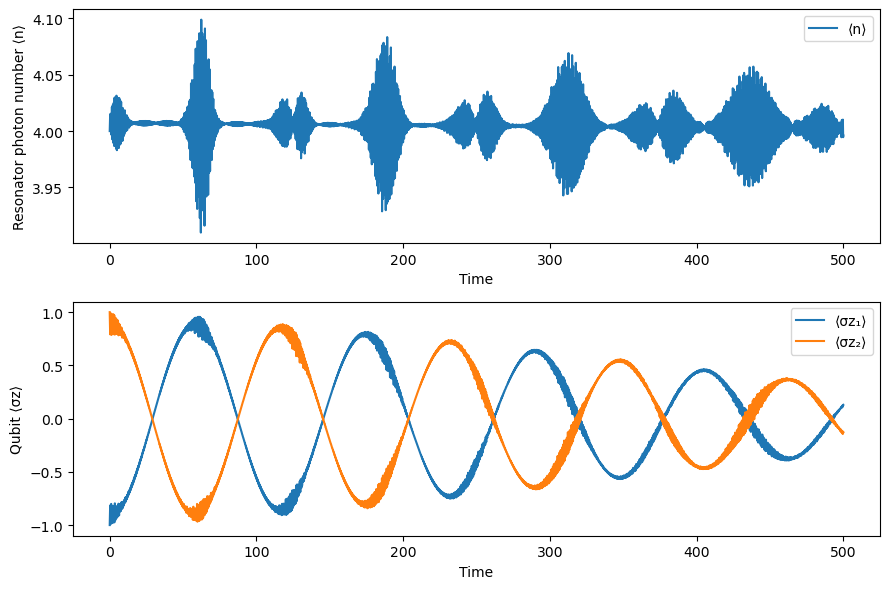

In [14]:
# Expectation values
photon_num = result0.expect[0]
sz1_vals = result0.expect[1]
sz2_vals = result0.expect[2]

fig, ax = plt.subplots(2, 1, figsize=(9,6))
ax[0].plot(tlist0, result0.expect[0], label="⟨n⟩")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Resonator photon number ⟨n⟩")
ax[0].legend()

ax[1].plot(tlist0, result0.expect[1], label="⟨σz₁⟩")
ax[1].plot(tlist0, result0.expect[2], label="⟨σz₂⟩")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Qubit ⟨σz⟩")
ax[1].legend()

plt.tight_layout()
plt.show()

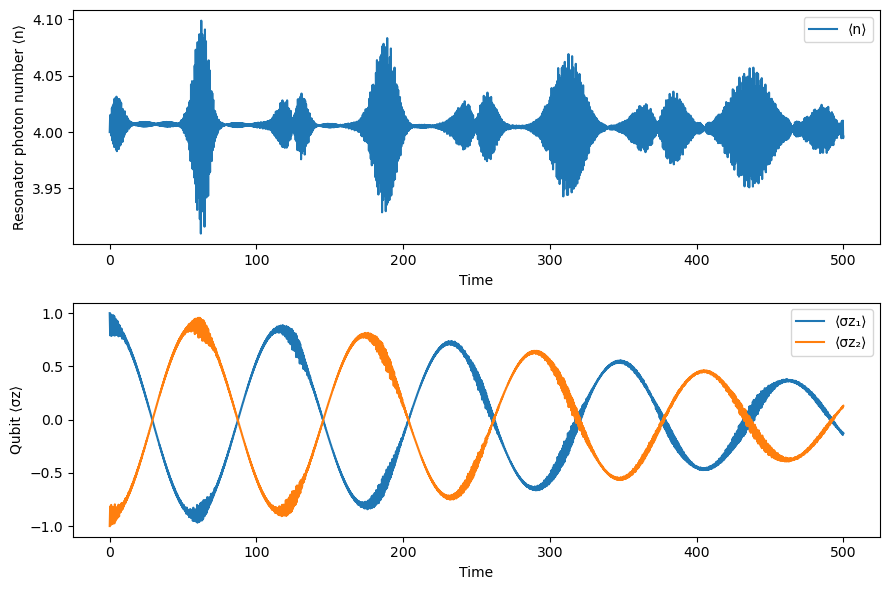

In [16]:
# Initial state, qubit state 01
psi1 = tensor(coherent(N,2), basis(2,0), basis(2,1))

result1 = mesolve(H, psi1, tlist0, c_ops0, [a.dag()*a, sz1, sz2])

# Expectation values
photon_num = result1.expect[0]
sz1_vals = result1.expect[1]
sz2_vals = result1.expect[2]

fig, ax = plt.subplots(2, 1, figsize=(9,6))
ax[0].plot(tlist0, result1.expect[0], label="⟨n⟩")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Resonator photon number ⟨n⟩")
ax[0].legend()

ax[1].plot(tlist0, result1.expect[1], label="⟨σz₁⟩")
ax[1].plot(tlist0, result1.expect[2], label="⟨σz₂⟩")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Qubit ⟨σz⟩")
ax[1].legend()

plt.tight_layout()
plt.show()

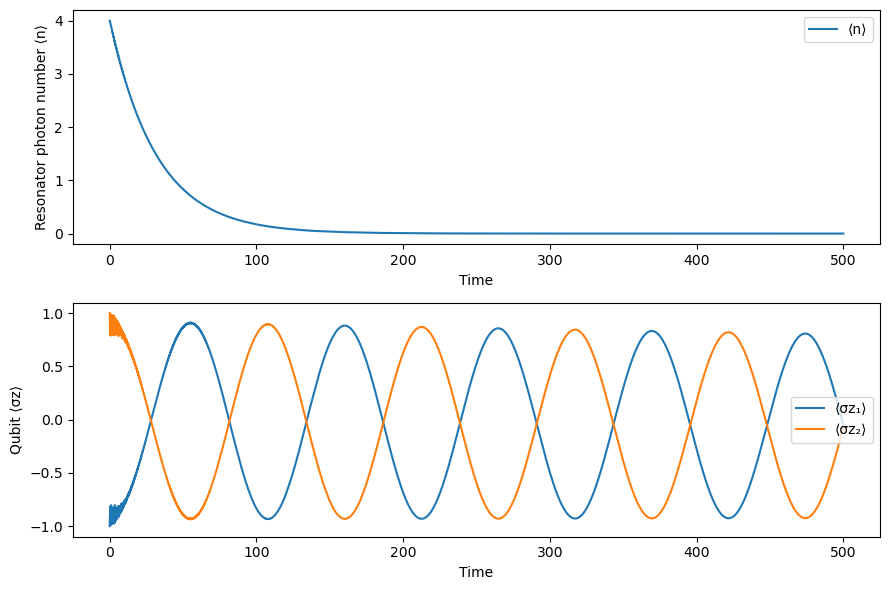

In [17]:
# Non-zero dissipation
gamma = 0.005 * 2 * np.pi
c_ops1 = [np.sqrt(gamma) * a]
result2 = mesolve(H, psi0, tlist0, c_ops1, [a.dag()*a, sz1, sz2])

photon_num = result2.expect[0]
sz1_vals = result2.expect[1]
sz2_vals = result2.expect[2]

fig, ax = plt.subplots(2, 1, figsize=(9,6))
ax[0].plot(tlist0, result2.expect[0], label="⟨n⟩")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Resonator photon number ⟨n⟩")
ax[0].legend()

ax[1].plot(tlist0, result2.expect[1], label="⟨σz₁⟩")
ax[1].plot(tlist0, result2.expect[2], label="⟨σz₂⟩")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Qubit ⟨σz⟩")
ax[1].legend()

plt.tight_layout()
plt.show()

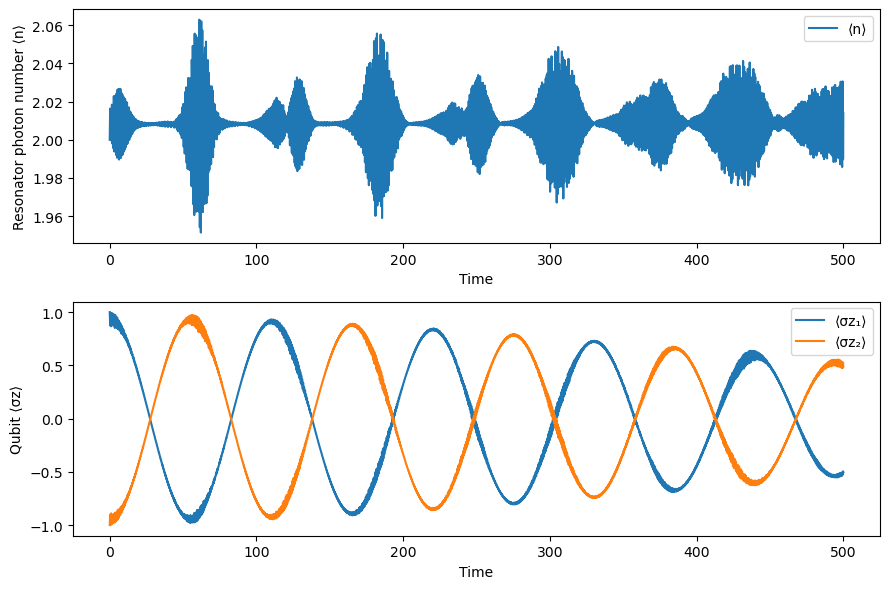

In [18]:
# Another initial state
psi3 = tensor(coherent(N,sqrt(2)), basis(2,0), basis(2,1))

result3 = mesolve(H, psi3, tlist0, c_ops0, [a.dag()*a, sz1, sz2])

# Expectation values
photon_num = result3.expect[0]
sz1_vals = result3.expect[1]
sz2_vals = result3.expect[2]

fig, ax = plt.subplots(2, 1, figsize=(9,6))
ax[0].plot(tlist0, result3.expect[0], label="⟨n⟩")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Resonator photon number ⟨n⟩")
ax[0].legend()

ax[1].plot(tlist0, result3.expect[1], label="⟨σz₁⟩")
ax[1].plot(tlist0, result3.expect[2], label="⟨σz₂⟩")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Qubit ⟨σz⟩")
ax[1].legend()

plt.tight_layout()
plt.show()

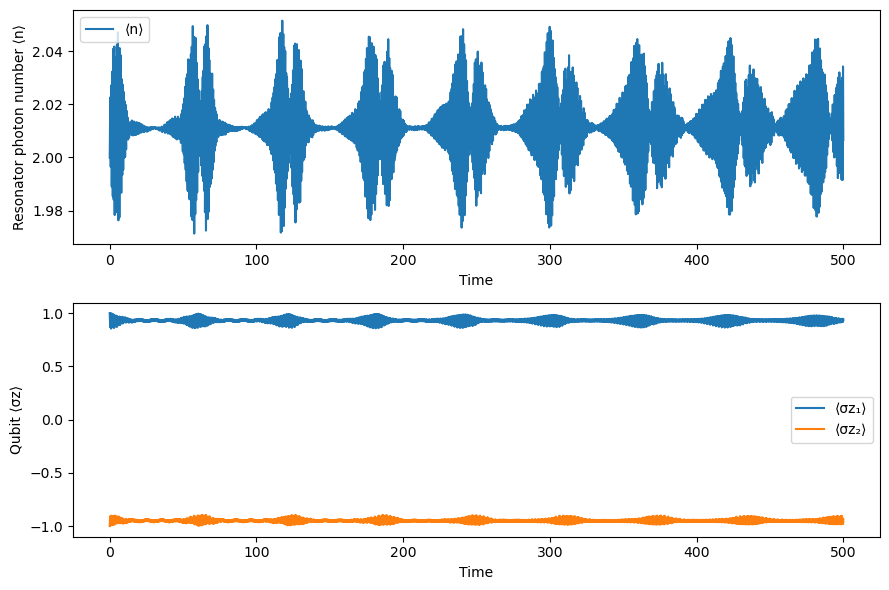

In [20]:
# Tune the qubit frequencies slightly to make them non-degenerate
wq_1 = 3.45 * 2 * pi     # qubit 1 frequency
wq_2 = 3.55 * 2 * pi     # qubit 2 frequency, degenerate qubits

# Qubit Hamiltonians
Hq_1 = (wq_1 / 2) * sz1
Hq_2 = (wq_2 / 2) * sz2

# Total Hamiltonian
H1 = Hq_1 + Hq_2 + Hr + Hint1 + Hint2

psi4 = tensor(coherent(N,sqrt(2)), basis(2,0), basis(2,1))

result4 = mesolve(H1, psi4, tlist0, c_ops0, [a.dag()*a, sz1, sz2])

fig, ax = plt.subplots(2, 1, figsize=(9,6))
ax[0].plot(tlist0, result4.expect[0], label="⟨n⟩")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Resonator photon number ⟨n⟩")
ax[0].legend()

ax[1].plot(tlist0, result4.expect[1], label="⟨σz₁⟩")
ax[1].plot(tlist0, result4.expect[2], label="⟨σz₂⟩")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Qubit ⟨σz⟩")
ax[1].legend()

plt.tight_layout()
plt.show()

Detune the qubit frequencies slightly and qubit-qubit interactions can be turned off!

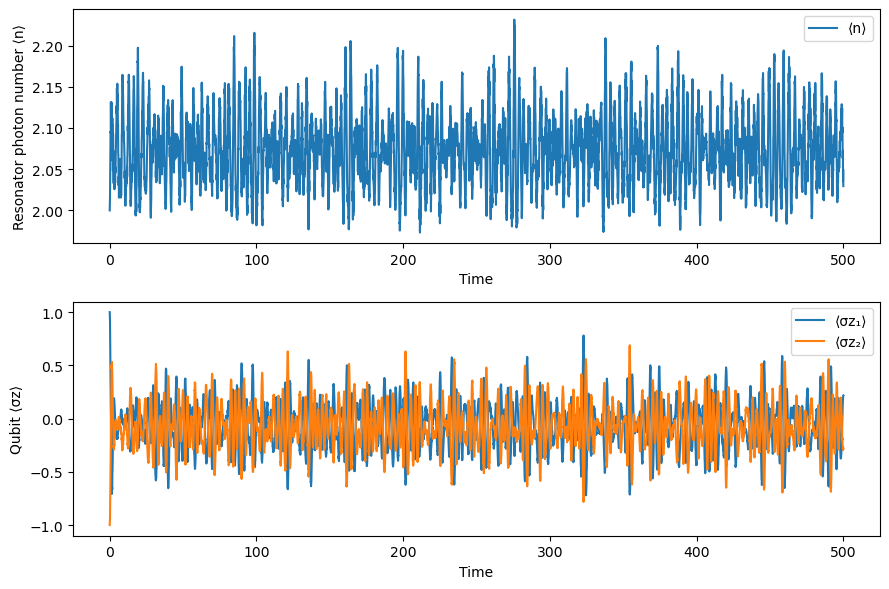

In [21]:
# Non-dissipative regime, where qubit and resonator frequencies are close
wq_1 = 2.05 * 2 * pi     # qubit 1 frequency
wq_2 = 2.05 * 2 * pi     # qubit 2 frequency, degenerate qubits

# Qubit Hamiltonians
Hq_1 = (wq_1 / 2) * sz1
Hq_2 = (wq_2 / 2) * sz2

# Total Hamiltonian
H1 = Hq_1 + Hq_2 + Hr + Hint1 + Hint2

psi4 = tensor(coherent(N,sqrt(2)), basis(2,0), basis(2,1))

result5 = mesolve(H1, psi4, tlist0, c_ops0, [a.dag()*a, sz1, sz2])

fig, ax = plt.subplots(2, 1, figsize=(9,6))
ax[0].plot(tlist0, result5.expect[0], label="⟨n⟩")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Resonator photon number ⟨n⟩")
ax[0].legend()

ax[1].plot(tlist0, result5.expect[1], label="⟨σz₁⟩")
ax[1].plot(tlist0, result5.expect[2], label="⟨σz₂⟩")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Qubit ⟨σz⟩")
ax[1].legend()

plt.tight_layout()
plt.show()